# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

In [1]:
install.packages("tidyverse")
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


---
## 1. Loading and formatting the data (2 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [12]:
# WRITE YOUR CODE HERE
incorrect_dat <- read_csv("https://raw.githubusercontent.com/m4tt-nm/martino_DSPN_S26/refs/heads/master/Exercise%20datasets/lexDat/LexicalData_withIncorrect.csv")
items_dat <- read_csv("https://raw.githubusercontent.com/m4tt-nm/martino_DSPN_S26/refs/heads/master/Exercise%20datasets/lexDat/Items.csv")
joined_dat <- incorrect_dat %>%
  left_join(items_dat, by = c("D_Word" = "Word")) %>%
  drop_na()

head(joined_dat)


New names:
• `` -> `...1`
Rows: 74869 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): D_Word
dbl (6): ...1, Sub_ID, Trial, Type, D_Zscore, Correct
num (1): D_RT
lgl (1): Outlier

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 30959 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Word
dbl (3): Occurrences, Length, Log_Freq_HAL
num (1): Freq_HAL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


...1,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Occurrences,Length,Freq_HAL,Log_Freq_HAL
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,157,1,1,710,browse,FALSE,-0.437,1,2,6,7016,8.856
2,67,1,1,1094,refrigerant,FALSE,0.825,1,3,11,104,4.644
3,120,1,1,587,gaining,FALSE,-0.645,1,4,7,4039,8.304
4,21,1,1,984,cheerless,FALSE,0.025,1,4,9,14,2.639
5,236,1,1,577,pattered,FALSE,-0.763,1,4,8,4,1.386
6,236,2,1,715,conjures,FALSE,-0.364,1,4,8,194,5.268


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

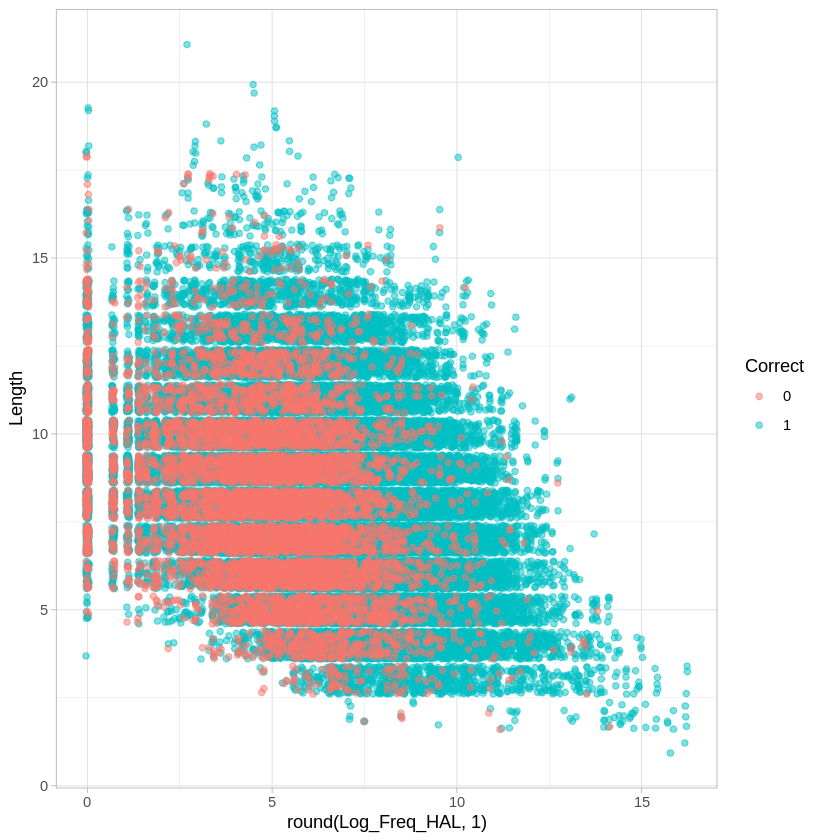

In [13]:
#vrequire(tidyverse) # Load the tidyverse package, if you haven't yet
joined_dat$Correct <- as.factor(joined_dat$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(joined_dat,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()


What do you observe about the "Correct" and "Incorrect" clusters?

> *The correct cluster is much larger than incorrect and maintains high density of observations within the entire space incorrect trials cover as well as wide portions outside of the space incorrect trials cover both in terms of length and log_freq_HAL,1*
>

---
## 3. Logistic Regression: Fitting the model (3 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [16]:
# WRITE YOUR CODE HERE
glm_joined <- glm(Correct ~ Length * Log_Freq_HAL,
    data = joined_dat,
    family = "binomial")

summary(glm_joined)




Call:
glm(formula = Correct ~ Length * Log_Freq_HAL, family = "binomial", 
    data = joined_dat)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

> Length, Log_Freq_HAL, and the interaction between the two predictors are all significant in predicting whether or not a trial is correct. The model suggests that increasing word length or common-ness of a word increase the probability of trials being responded to correctly, but the positive effects of one of these predictors is diminishing when increasing the other.

---


>

---
## 4. Interpreting predictions from the model (4 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [33]:
# WRITE YOUR CODE HERE
THRESHOLD <- 0.5


glm_pred_df <- glm_joined %>%
    predict(type = "response") %>%
    as.data.frame()

colnames(glm_pred_df)[1] <- 'predicted_prob'

num_observations <- nrow(glm_pred_df)

glm_pred_df$predicted_binary <- rep(0,num_observations)
glm_pred_df$predicted_binary[glm_pred_df$predicted_prob>THRESHOLD] <- 1

confusion_df <- data.frame(glm_pred_df$predicted_binary, joined_dat$Correct)
colnames(confusion_df) <- c("Predicted", "Actual")
table(confusion_df)

confusion_df$Predicted <- factor(confusion_df$Predicted, levels = c(0,1))
confusion_df$Actual <- factor(confusion_df$Actual, levels = c(0,1))

print(paste("Accuracy:",mean(confusion_df$Predicted == confusion_df$Actual)))


         Actual
Predicted     0     1
        0    13    44
        1  7966 62566

[1] "Accuracy: 0.886526229299183"


Did the model do well at predicting lexical decision correctness? Why or why not?

> *The model does a good job at getting hits and avoiding misses for correct trials, but 7966 false alarms compared to 13 correct rejections makes it bad at predicting incorrect trials. So, while the model is highly accurate do to the overwhelming density of correct trials relative to incorrect, I wouldn't trust it to accurately predict incorrect trials.*  
>

**DUE:** 11:59pm EST, March 3, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *No*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
>No but I clicked the gemini "explain error" button by mistake in Colab and it started messing up my code